# 03 - Exploratory Data Analysis (EDA)

Objective: Analyze trends, distributions, and outliers from the cleaned Blinkit dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

try:
    import seaborn as sns
    sns.set_theme(style='whitegrid')
except Exception:
    sns = None

pd.set_option('display.max_columns', 100)

DATA_PATH = '../data/processed/blinkit_cleaned_dashboard_data.csv'
df = pd.read_csv(DATA_PATH)

for c in ['order_date', 'registration_date', 'feedback_date', 'promised_time', 'actual_time']:
    if c in df.columns:
        df[c] = pd.to_datetime(df[c], errors='coerce')

df.head()

Matplotlib is building the font cache; this may take a moment.


,order_id,customer_id,order_date,order_total,payment_method,delivery_partner_id,store_id,hour,day,month,weekday,product_id,quantity,unit_price,total_price,product_name,category,brand,mrp,margin_percentage,shelf_life_days,min_stock_level,max_stock_level,area,pincode,registration_date,customer_segment,total_orders,avg_order_value,promised_time,actual_time,delivery_time_minutes,distance_km,reasons_if_delayed,is_delayed,delay_minutes,feedback_id,rating,feedback_text,feedback_category,sentiment,feedback_date,promised_duration_minutes,actual_duration_minutes,delivery_efficiency,order_size,is_peak,delay_category,delivery_status,delay_bucket,order_value_bucket
0,1961864118,30065862,2024-07-17 08:34:01,3197.07,Cash,63230,4771,8,17,7,Wednesday,642612,3,517.03,1551.09,Pet Treats,Pet Care,Pillay-Ahuja,795.43,35.0,365,16,57,Allahabad,911359,2024-09-02,Regular,13,749.95,2024-07-17 08:52:01,2024-07-17 08:47:01,-5.0,0.96,On Time,False,0.0,2234710,4,"It was okay, nothing special.",Delivery,Neutral,2024-07-17,18.0,13.0,1.384615,3,True,Low Delay,On Time / Early,0-5 min,High
1,1549769649,9573071,2024-05-28 13:14:29,976.55,Cash,14983,7534,13,28,5,Tuesday,378676,1,881.42,881.42,Orange Juice,Cold Drinks & Juices,Baral-Kamdar,1259.17,30.0,180,19,65,Thrissur,856100,2023-11-07,New,5,958.06,2024-05-28 13:25:29,2024-05-28 13:27:29,2.0,0.98,Traffic,True,2.0,5450964,3,The order was incorrect.,App Experience,Negative,2024-05-28,11.0,13.0,0.846154,1,False,Low Delay,Delayed,0-5 min,Low
2,9185164487,45477575,2024-09-23 13:07:12,839.05,UPI,39859,9886,13,23,9,Monday,741341,2,923.84,1847.68,Eggs,Dairy & Breakfast,Prasad LLC,1154.80,20.0,7,13,62,Vellore,117423,2024-01-05,Inactive,4,327.93,2024-09-23 13:25:12,2024-09-23 13:29:12,4.0,3.83,Traffic,True,4.0,482108,3,"It was okay, nothing special.",App Experience,Neutral,2024-09-23,18.0,22.0,0.818182,2,False,Low Delay,Delayed,0-5 min,Low
3,9644738826,88067569,2023-11-24 16:16:56,440.23,Card,61497,7917,16,24,11,Friday,561860,1,874.78,874.78,Orange Juice,Cold Drinks & Juices,Gupta Ltd,1249.69,30.0,180,21,90,Gaya,288459,2023-12-25,Premium,5,273.38,2023-11-24 16:34:56,2023-11-24 16:33:56,-1.0,2.76,On Time,False,0.0,4823104,4,The product met my expectations.,App Experience,Neutral,2023-11-24,18.0,17.0,1.058824,1,False,Low Delay,On Time / Early,0-5 min,Low
4,5427684290,83298567,2023-11-20 05:00:39,2526.68,Cash,84315,2741,5,20,11,Monday,602241,2,976.55,1953.10,Nuts,Snacks & Munchies,Bahl-Pau,1502.38,35.0,90,12,75,Asansol,149383,2024-10-02,Premium,14,763.10,2023-11-20 05:17:39,2023-11-20 05:18:39,1.0,2.63,Traffic,True,1.0,3537464,3,Product was damaged during delivery.,Delivery,Negative,2023-11-20,17.0,18.0,0.944444,2,False,Low Delay,Delayed,0-5 min,Medium


In [2]:
print(f'Shape: {df.shape}')
print('\nColumn Types:')
print(df.dtypes.sort_index())

missing = df.isna().mean().sort_values(ascending=False).mul(100).round(2)
print('\nMissing % (top 20):')
display(missing.head(20))

numeric_cols = df.select_dtypes(include=[np.number]).columns
cat_cols = df.select_dtypes(exclude=[np.number]).columns

print(f'Numeric columns: {len(numeric_cols)}')
print(f'Categorical/Date columns: {len(cat_cols)}')
display(df[numeric_cols].describe().T.head(20))

Shape: (5000, 51)

Column Types:
actual_duration_minutes             float64
actual_time                  datetime64[us]
area                                    str
avg_order_value                     float64
brand                                   str
category                                str
customer_id                           int64
customer_segment                        str
day                                   int64
delay_bucket                            str
delay_category                          str
delay_minutes                       float64
delivery_efficiency                 float64
delivery_partner_id                   int64
delivery_status                         str
delivery_time_minutes               float64
distance_km                         float64
feedback_category                       str
feedback_date                datetime64[us]
feedback_id                           int64
feedback_text                           str
hour                                  int64

order_id                     0.0
feedback_text                0.0
avg_order_value              0.0
promised_time                0.0
actual_time                  0.0
delivery_time_minutes        0.0
distance_km                  0.0
reasons_if_delayed           0.0
is_delayed                   0.0
delay_minutes                0.0
feedback_id                  0.0
rating                       0.0
feedback_category            0.0
customer_segment             0.0
sentiment                    0.0
feedback_date                0.0
promised_duration_minutes    0.0
actual_duration_minutes      0.0
delivery_efficiency          0.0
order_size                   0.0
dtype: float64

Numeric columns: 29
Categorical/Date columns: 22


,count,mean,std,min,25%,50%,75%,max
order_id,5000.0,5.029129e+09,2.863533e+09,60465.00,2.531421e+09,5.074378e+09,7.488579e+09,9.998298e+09
customer_id,5000.0,5.009685e+07,2.919082e+07,31813.00,2.404314e+07,4.997808e+07,7.621215e+07,9.989390e+07
order_total,5000.0,2.201862e+03,1.303024e+03,13.25,1.086215e+03,2.100690e+03,3.156883e+03,6.721460e+03
delivery_partner_id,5000.0,5.005032e+04,2.880228e+04,43.00,2.492850e+04,5.026250e+04,7.447825e+04,9.996800e+04
store_id,5000.0,4.999689e+03,2.886089e+03,1.00,2.509250e+03,4.987000e+03,7.500750e+03,9.995000e+03
hour,5000.0,1.152260e+01,6.945901e+00,0.00,5.750000e+00,1.200000e+01,1.800000e+01,2.300000e+01
day,5000.0,1.577840e+01,8.784892e+00,1.00,8.000000e+00,1.600000e+01,2.300000e+01,3.100000e+01
month,5000.0,6.643600e+00,3.058701e+00,1.00,4.000000e+00,7.000000e+00,9.000000e+00,1.200000e+01
product_id,5000.0,5.099749e+05,2.936783e+05,4452.00,2.577190e+05,5.406180e+05,7.478010e+05,9.933310e+05
quantity,5000.0,2.006800e+00,8.205415e-01,1.00,1.000000e+00,2.000000e+00,3.000000e+00,3.000000e+00


## Trends Analysis

In [3]:
order_level = df.sort_values('order_date').drop_duplicates('order_id').copy()

order_level['order_month'] = order_level['order_date'].dt.to_period('M').astype(str)
order_level['order_week'] = order_level['order_date'].dt.to_period('W').astype(str)

monthly = order_level.groupby('order_month', as_index=False).agg(
    orders=('order_id', 'nunique'),
    revenue=('order_total', 'sum'),
    avg_order_value=('order_total', 'mean')
)

weekday_perf = order_level.groupby('weekday', as_index=False).agg(
    orders=('order_id', 'nunique'),
    revenue=('order_total', 'sum')
)

weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekday_perf['weekday'] = pd.Categorical(weekday_perf['weekday'], categories=weekday_order, ordered=True)
weekday_perf = weekday_perf.sort_values('weekday')

display(monthly.tail(12))
display(weekday_perf)

,order_month,orders,revenue,avg_order_value
9,2023-12,268,615709.03,2297.421754
10,2024-01,270,560423.56,2075.642815
11,2024-02,252,545090.11,2163.055992
12,2024-03,251,543181.85,2164.071116
13,2024-04,241,538754.75,2235.496888
14,2024-05,263,574163.61,2183.131597
15,2024-06,248,539074.85,2173.688911
16,2024-07,256,573111.98,2238.718672
17,2024-08,251,546194.57,2176.073984
18,2024-09,247,518695.03,2099.979879


,weekday,orders,revenue
1,Monday,687,1485228.74
5,Tuesday,705,1518415.49
6,Wednesday,744,1642278.55
4,Thursday,720,1578117.32
0,Friday,715,1565104.48
2,Saturday,706,1549025.34
3,Sunday,723,1671138.58


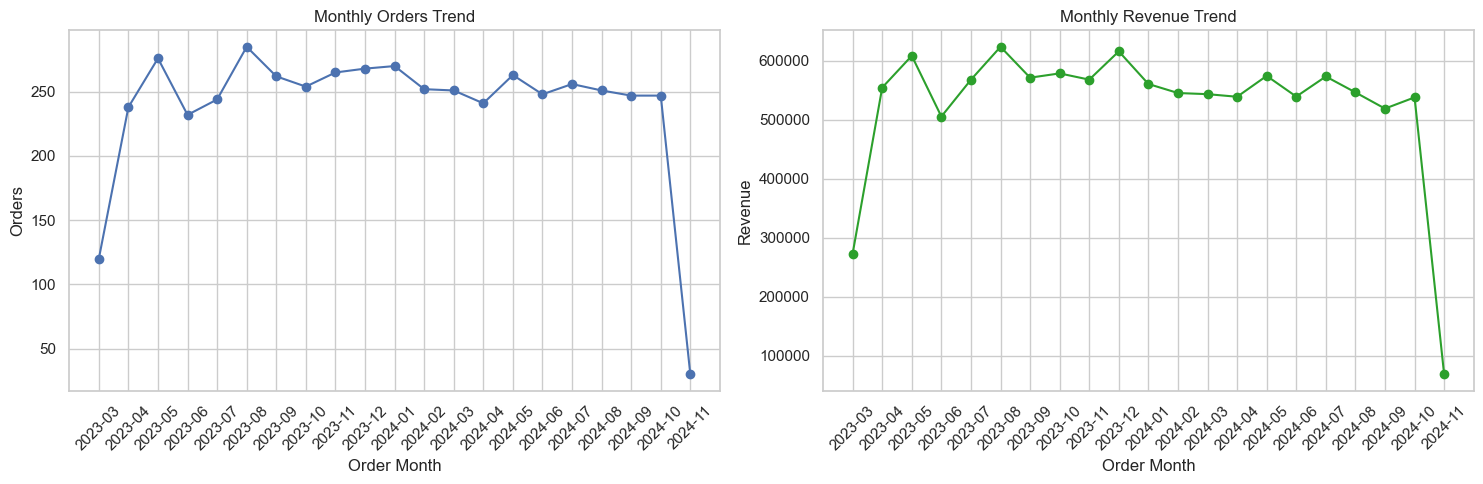

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(monthly['order_month'], monthly['orders'], marker='o')
axes[0].set_title('Monthly Orders Trend')
axes[0].set_xlabel('Order Month')
axes[0].set_ylabel('Orders')
axes[0].tick_params(axis='x', rotation=45)

axes[1].plot(monthly['order_month'], monthly['revenue'], marker='o', color='tab:green')
axes[1].set_title('Monthly Revenue Trend')
axes[1].set_xlabel('Order Month')
axes[1].set_ylabel('Revenue')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Distribution Analysis

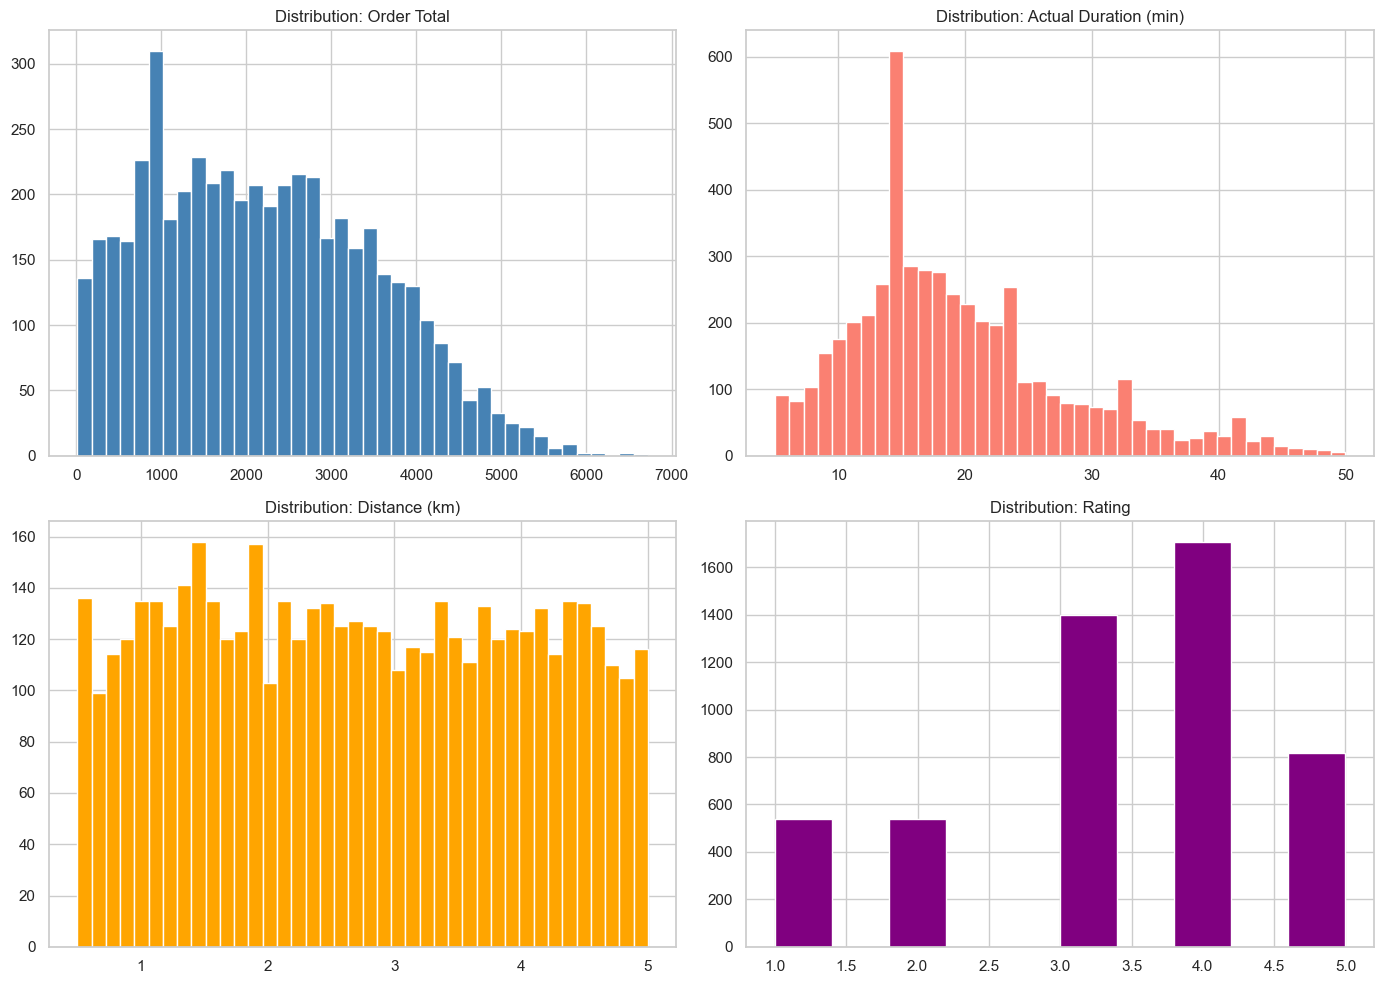

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].hist(order_level['order_total'].dropna(), bins=40, color='steelblue', edgecolor='white')
axes[0, 0].set_title('Distribution: Order Total')

axes[0, 1].hist(order_level['actual_duration_minutes'].dropna(), bins=40, color='salmon', edgecolor='white')
axes[0, 1].set_title('Distribution: Actual Duration (min)')

axes[1, 0].hist(order_level['distance_km'].dropna(), bins=40, color='orange', edgecolor='white')
axes[1, 0].set_title('Distribution: Distance (km)')

axes[1, 1].hist(order_level['rating'].dropna(), bins=10, color='purple', edgecolor='white')
axes[1, 1].set_title('Distribution: Rating')

plt.tight_layout()
plt.show()

## Outlier Detection (IQR Method)

In [6]:
def iqr_outlier_summary(series: pd.Series, label: str) -> dict:
    s = series.dropna()
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    mask = (series < lower) | (series > upper)
    return {
        'metric': label,
        'q1': q1,
        'q3': q3,
        'iqr': iqr,
        'lower_bound': lower,
        'upper_bound': upper,
        'outlier_count': int(mask.sum()),
        'outlier_pct': round(100 * mask.mean(), 2)
    }

outlier_report = pd.DataFrame([
    iqr_outlier_summary(order_level['order_total'], 'order_total'),
    iqr_outlier_summary(order_level['actual_duration_minutes'], 'actual_duration_minutes'),
    iqr_outlier_summary(order_level['distance_km'], 'distance_km'),
    iqr_outlier_summary(order_level['rating'], 'rating')
])

display(outlier_report)

high_value_outliers = order_level[
    order_level['order_total'] > outlier_report.loc[outlier_report['metric'] == 'order_total', 'upper_bound'].iloc[0]
][['order_id', 'order_date', 'customer_segment', 'order_total', 'distance_km', 'actual_duration_minutes', 'rating']]

display(high_value_outliers.sort_values('order_total', ascending=False).head(20))

,metric,q1,q3,iqr,lower_bound,upper_bound,outlier_count,outlier_pct
0,order_total,1086.215,3156.8825,2070.6675,-2019.78625,6262.88375,3,0.06
1,actual_duration_minutes,13.000,24.0000,11.0000,-3.50000,40.50000,161,3.22
2,distance_km,1.590,3.8500,2.2600,-1.80000,7.24000,0,0.00
3,rating,3.000,4.0000,1.0000,1.50000,5.50000,540,10.80


,order_id,order_date,customer_segment,order_total,distance_km,actual_duration_minutes,rating
2231,7908614088,2023-05-14 15:42:09,Inactive,6721.46,2.89,34.0,3
534,7589464630,2024-07-12 13:13:16,Premium,6543.19,4.41,26.0,5
3473,5211751826,2023-08-31 01:45:48,Regular,6458.90,0.53,21.0,1


## Category And Segment Insights

In [7]:
cat_perf = df.groupby('category', as_index=False).agg(
    revenue=('total_price', 'sum'),
    units_sold=('quantity', 'sum'),
    avg_unit_price=('unit_price', 'mean')
).sort_values('revenue', ascending=False)

segment_perf = order_level.groupby('customer_segment', as_index=False).agg(
    orders=('order_id', 'nunique'),
    revenue=('order_total', 'sum'),
    avg_order_value=('order_total', 'mean'),
    avg_rating=('rating', 'mean')
).sort_values('revenue', ascending=False)

display(cat_perf.head(15))
display(segment_perf)

,category,revenue,units_sold,avg_unit_price
2,Dairy & Breakfast,639222.19,1114,574.776396
9,Pharmacy,592368.57,973,601.520021
3,Fruits & Vegetables,559053.08,966,566.480488
8,Pet Care,539888.75,1003,535.208583
5,Household Care,444244.25,1078,409.000511
7,Personal Care,394894.61,887,438.945947
10,Snacks & Munchies,394648.71,963,417.271884
1,Cold Drinks & Juices,392717.62,758,517.329040
4,Grocery & Staples,359937.82,895,400.935590
0,Baby Care,348227.18,655,521.659311


,customer_segment,orders,revenue,avg_order_value,avg_rating
3,Regular,1320,2890148.66,2189.506561,3.351515
1,New,1222,2795854.48,2287.933290,3.339607
2,Premium,1268,2731329.71,2154.045513,3.320978
0,Inactive,1190,2591975.65,2178.130798,3.366387
